## Exercise 1 Extra 1
_Using `mlflow, LinearRegression, bottled_rage_of_low_metrics_from_previous_exercises`_

<br>
<br>

<i>


### Dataset: [Drug Seizures](https://www.kaggle.com/datasets/kindasomethin/drug-seizures-2019-2023)


|Parameter|Description|
|---|---|
|Shape|`11k rows, 9 columns`|
|Target Variable|`Kilograms`|
|Method:|`LinearRegression`
|Extra Tools:|`mlflow`|

### Columns Descriptions


<strong style='color:red ; background-color:black;'> 

#### Disclosure: 
I used AI to convert the table from the kaggle dataset webpage into a markdown table.


#### Prompt:
 /paste Kaggle column descriptions/. 

 Could you put this into a markdown table for me? 

</strong>


#### Column Descriptions:

| Variable      | Description                              |
| ------------- | ---------------------------------------- |
| MedInc        | Median income in block group             |
| HouseAge      | Median house age in block group          |
| AveRooms      | Average number of rooms per household    |
| AveBedrms     | Average number of bedrooms per household |
| Population    | Block group population                   |
| AveOccup      | Average household size                   |
| Latitude      | Block group latitude                     |
| Longitude     | Block group longitude                    |
| MedHouseValue | Median house value                       |


#### Summary:

<i>
This is a notebook which let's me build some confidence with the introduced approaches. My notebooks so far haven't really obtained any notably good results.
Practice makes perfect so let's try to get some good results with this notebook. 
</i>

#### Results:

<i>
Add Text Here.
</i>

<br>
<br>


---

## Code:

#### Imports and Data Loading

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import mlflow

# Loading the dataset
df = pd.read_csv("datasets/drug_seizures.csv")
df.head(3)

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms,msCode
0,Africa,East Africa,Comoros,Any other drugs/substances,Other miscellaneous,Other drugs/substances,2023,45.0,COM
1,Africa,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2023,2263.0,COM
2,Africa,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis resin (hashish),Cannabis resin (hashish),2023,57.5,COM


---

### Data Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation & Feature Engineering|
|3| ML Training & Metrics|

#### Checking the Shape

In [2]:
# Checking the rows and columns
df.shape

(11274, 9)

#### Handling Missing Values

In [3]:
# Checking for missing values
df.isna().sum()

# 76 / 11k rows. Neglible amount of rows to drop and it's not a timeseries.
# Let's drop them

Region             0
SubRegion          0
Country            0
DrugGroup          0
DrugSubGroup       0
DrugName           0
Reference year     0
Kilograms         76
msCode             0
dtype: int64

In [4]:
# Dropping Missing values.
df = df.dropna()

#### Checking Duplicates

In [5]:
# Checking for duplicates
df.duplicated().sum()

# Some duplicates as well, let's drop those too

np.int64(236)

In [6]:
# Dropping duplicates
df = df.drop_duplicates()

#### Dropping Columns

In [7]:
df.head(3)

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms,msCode
0,Africa,East Africa,Comoros,Any other drugs/substances,Other miscellaneous,Other drugs/substances,2023,45.0,COM
1,Africa,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2023,2263.0,COM
2,Africa,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis resin (hashish),Cannabis resin (hashish),2023,57.5,COM


#### Checking for Nonsensical Values

In [8]:
# Are there any weights under zero?
df[df["Kilograms"] < 0]

# Seems fine.

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms,msCode


In [9]:
# Are there any years before 2019 and after 2023?
# That wouldn't make sense since the Kaggle description
# Said it was in this range

df[
    (df["Reference year"] > 2023) |
    (df["Reference year"] < 2019)
]

# It's fine.

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms,msCode


In [10]:
# Dropping unneeded columns.
df = df.drop([
    "Region",
    "msCode"
    ], axis=1)          # 99% this will be multicollinear with Subregion

# I'm not dropping Subregion because they might still be statistically valid and not completely
# redundant.

#### Checking for Isolated Cases in Categorical Values

`Subregion`

In [11]:
# Checking value counts starting with the fewest counts.
df["SubRegion"].value_counts().reset_index().sort_values("count")

# No problems here.

,SubRegion,count
15,Caribbean,97
14,East Africa,129
13,South Asia,205
12,Southern Africa,217
11,North Africa,223
10,Central America,237
9,Eastern Europe,394
8,Central Asia and Transcaucasia,440
7,West and Central Africa,513
6,Near and Middle East/ South-West Asia,530


In [12]:
df.head(3)

,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms
0,East Africa,Comoros,Any other drugs/substances,Other miscellaneous,Other drugs/substances,2023,45.0
1,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2023,2263.0
2,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis resin (hashish),Cannabis resin (hashish),2023,57.5


`Country`

In [13]:
# Checking value counts starting with the fewest counts.
df["Country"].value_counts().reset_index().sort_values("count")

# This is an issue, because there's way too few cases for these.
# Let's filter out any countries that have less than 10 cases.

,Country,count
163,Holy See,1
161,Seychelles,2
162,Timor-Leste,2
158,Angola,3
159,Democratic Republic of the Congo,3
...,...,...
4,Sweden,270
3,Switzerland,283
2,Argentina,297
1,Australia,374


In [14]:
# DISCLOSURE, I TOOK THIS FROM AI:

# PROMPT: I don't remember, it was a little while ago (maybe 3 months ago).
# I since have been using it as a copy-paste

# MODEL: ChatGPT 4.0

# ------------------------------------

# We'll use a groupby lambda to filter out any cases.

# We count the number of rows using len(x) by country.
# If the country is under 10, get out. 
df = df.groupby("Country").filter(lambda x: len(x) >= 10)
df.head(3)

,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms
9,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2020,12911.00
10,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis plants,Cannabis plants,2020,814.80
11,East Africa,Kenya,Cocaine-type,Cocaine,Cocaine hydrochloride,2020,0.35


`DrugGroup`

In [15]:
# Checking value counts starting with the fewest counts.
df["DrugGroup"].value_counts().reset_index().sort_values("count")

# That seems ok.

,DrugGroup,count
10,Solvents and Inhalants,17
9,Precursors,294
8,Any other drugs/substances,316
7,NPS,565
6,“Ecstasy”-type substances,669
5,Hallucinogens,776
4,Cocaine-type,933
3,Sedatives and tranquillizers,1053
2,Amphetamine-type stimulants (excluding “ecstasy”),1448
1,Cannabis-type drugs (excluding synthetic canna...,2144


`DrugsSubGroup`

In [16]:
# Checking value counts starting with the fewest counts.
df["DrugSubGroup"].value_counts().reset_index().sort_values("count")

# Same deal, not enough cases.

,DrugSubGroup,count
48,Aminoindanes,1
47,Opioids,1
46,Other/non-specified coca/cocaine-type drugs OR...,3
45,Tryptamines,4
42,Non-specified hallucinogens,6
43,Methaqualone,6
44,Other NPS,6
41,Piperazines,8
40,Substances not under int. control,10
39,Non-specified amphetamine-type stimulants,11


In [17]:
# DISCLOSURE, I TOOK THIS FROM AI:

# PROMPT: I don't remember, it was a little while ago (maybe 3 months ago).
# I since have been using it as a copy-paste

# MODEL: ChatGPT 4.0

# ------------------------------------

# We'll use a groupby lambda to filter out any cases.

# We count the number of rows using len(x) by country.
# If the country is under 10, get out. 
df = df.groupby("DrugSubGroup").filter(lambda x: len(x) >= 10)
df.head(3)

,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms
9,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2020,12911.00
10,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis plants,Cannabis plants,2020,814.80
11,East Africa,Kenya,Cocaine-type,Cocaine,Cocaine hydrochloride,2020,0.35


`DrugName`

In [18]:
# Now let's look at all the drug names.
df["DrugName"].value_counts().reset_index().sort_values("count")

# Lots of isolated cases that can't really be used for any statistical significance

,DrugName,count
144,Phenethylamine,1
145,MDEA,1
139,Non-specified,1
138,Adderall,1
148,Alpha-PHpP (PV8),1
...,...,...
4,Cannabis resin (hashish),468
3,Cocaine hydrochloride,513
2,Methamphetamine,542
1,Heroin,585


In [19]:
# DISCLOSURE, I TOOK THIS FROM AI:

# PROMPT: I don't remember, it was a little while ago (maybe 3 months ago).
# I since have been using it as a copy-paste

# MODEL: ChatGPT 4.0

# ------------------------------------

# We'll use a groupby lambda to filter out any cases.

# We count the number of rows using len(x) by country.
# If the country is under 10, get out. 
df = df.groupby("DrugName").filter(lambda x: len(x) >= 10)
df.head(3)

# 10,566 rows left -- We're still fine.

,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms
9,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2020,12911.00
10,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis plants,Cannabis plants,2020,814.80
11,East Africa,Kenya,Cocaine-type,Cocaine,Cocaine hydrochloride,2020,0.35


#### Turning All Columns Into Numeric 

#### Categorical

In [20]:
# OneHotEncoder
# This turns all categorical columns into binary, separate columns.
categorical_columns = ["SubRegion","Country", "DrugGroup", "DrugSubGroup", "DrugName"]

for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)

# This is going to create A METRIC TON of columns.

# Dropping one possible value of each value-count. Since 
# these can be deduced by all binary features of the column
# being 0.
df = df.drop([
    "SubRegion_East Africa",
    "Country_Kenya",
    "DrugGroup_Cocaine-type",
    "DrugName_Cocaine hydrochloride"
], axis=1)

---

### Transformation & Feature Engineering

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|<bold style="background:yellow;color:black;">  Transformation & Feature Engineering</bold>|
|3| ML Training & Metrics|

In [21]:
# Let's make an experiment df so we can see what transformations work.
df_copy = df 

#### Checking the Distribution of the Target Variable

<Axes: xlabel='Kilograms', ylabel='Count'>

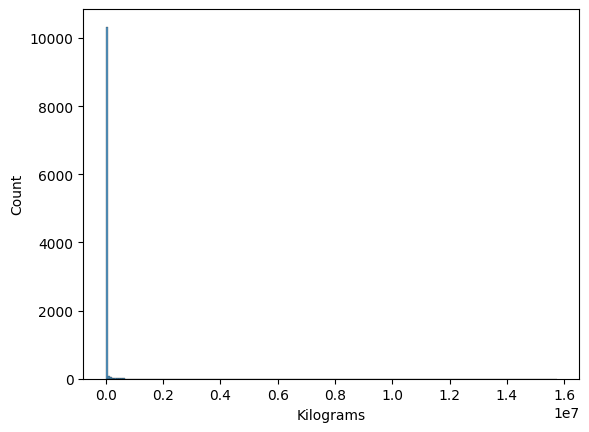

In [22]:
# Let's look at the distribution 
sns.histplot(df, x='Kilograms')

# StandardScaler might work well here. But it might not help the skew.

# Maybe Log1p or YeoJohnson

<i>
Oh dear, there must be some isolated case where A LOT. and I mean A LOT of drugs were seized. Let's figure out how much that is, I'm curious.

In [23]:
# Find the row with the highest amount of Kilograms seized
df['Kilograms'].max()

# FIFTEEN MILLION KILOGRAMS???

# Let's learn more.


np.float64(15734375.8)

In [24]:
# Filtering out the row with the millions of Kilos
df[df['Kilograms'] > 15000000]

# Wow, very interesting. Sorry, that was a tangent. Let's continue.

,Reference year,Kilograms,SubRegion_Australia and New Zealand,SubRegion_Caribbean,SubRegion_Central America,SubRegion_Central Asia and Transcaucasia,SubRegion_East and South-East Asia,SubRegion_Eastern Europe,SubRegion_Near and Middle East/ South-West Asia,SubRegion_North Africa,...,DrugName_Synthetic cannabinoids (Spice),DrugName_Synthetic cannabinoids (“Spice”),DrugName_Synthetic cannabinoids under international control,DrugName_Synthetic cathinones,"DrugName_Total ""ecstasy""-type substances (including the above, all other substances of this type and any unspecified/undistinguished quantities of substances of this type)","DrugName_Total amphetamine-type stimulants (ATS) (including the above, all other ATS, and any unspecified/undistinguished quantities of ATS)","DrugName_Total hallucinogens (including the above, all other hallucinogens, and any unspecified/undistinguished quantities of hallucinogens)","DrugName_Total sedatives and tranquillizers (including the above, all other sedatives and tranquillizers, and any unspecified/undistinguished quantities of sedatives and tranquillizers)",DrugName_Tramadol,DrugName_“Yaba”
6442,2023,15734375.8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Text(0.5, 1.0, 'StandardScaler')

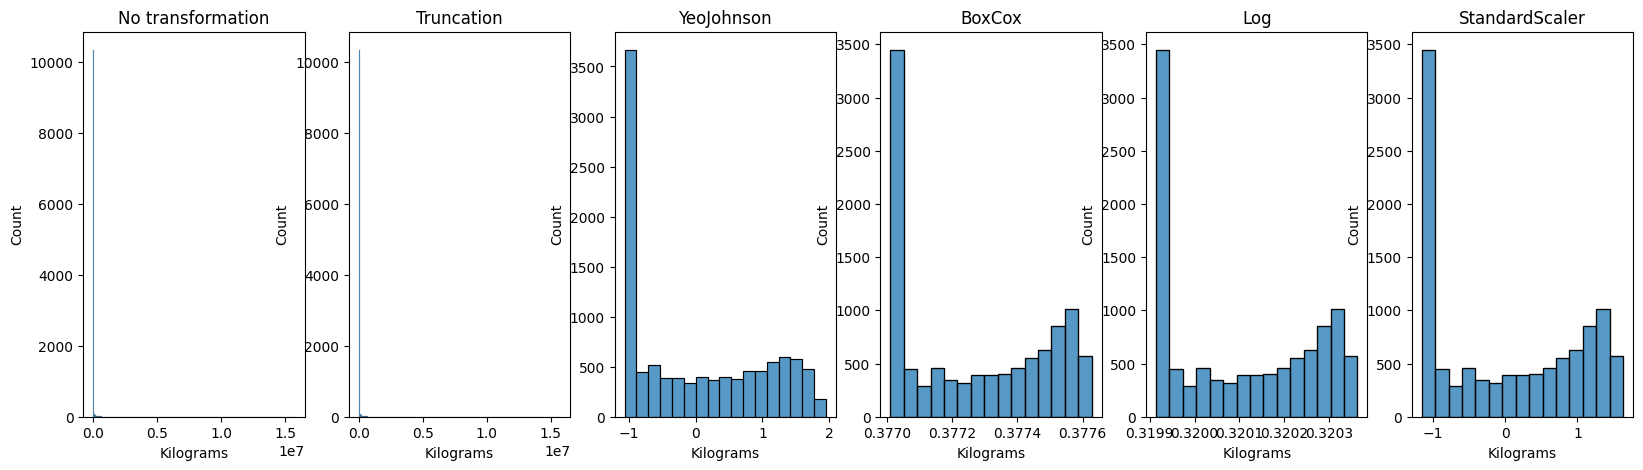

In [25]:
from sklearn.preprocessing import PowerTransformer
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Let's just get rid of all of the outliers over 3 standard deviations out
# for the features AND the target variable. 
Y_TRUNC = .90

# Let's make a canvas, we put our plots here.
fig, axes = plt.subplots(1, 6, figsize=(20, 5))

# HISTPLOT 1 -- No transformation
sns.histplot(df_copy, x="Kilograms", ax=axes[0])


# HISTPLOT 2 -- Truncation

# df_copy = df_copy[df_copy["Kilograms"] < df_copy["Kilograms"].quantile(Y_TRUNC)]

sns.histplot(df_copy, x="Kilograms", ax=axes[1])

# HISTPLOT 3 -- yeojohnson
pt = PowerTransformer(method='yeo-johnson')
df_copy_yeo = df_copy
df_copy_yeo["Kilograms"] = pt.fit_transform(df_copy_yeo[["Kilograms"]])
sns.histplot(df_copy_yeo, x="Kilograms", ax=axes[2])

# HISTPLOT 4 -- boxcox 
df_copy_bc = df_copy
df_copy_bc['Kilograms'], _ = stats.boxcox(df_copy_bc['Kilograms'] + 10) 
sns.histplot(df_copy_bc, x="Kilograms", ax=axes[3])

# HISTPLOT 5 -- Log
df_copy_log = df_copy
df_copy_log['Kilograms'] = np.log1p(df_copy_log['Kilograms'])
sns.histplot(df_copy_log, x="Kilograms", ax=axes[4])

# HISTPLOT 6 -- StandardScaler
df_copy_ss = df_copy
df_copy_ss['Kilograms'] = StandardScaler().fit_transform(df_copy_ss[['Kilograms']])
sns.histplot(df_copy_ss, x="Kilograms", ax=axes[5])

# TITLES
axes[0].set_title("No transformation")
axes[1].set_title("Truncation")
axes[2].set_title("YeoJohnson")
axes[3].set_title("BoxCox")
axes[4].set_title("Log")
axes[5].set_title("StandardScaler")

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<i>

<h3>Observations</h3>

Let's pick YeoJohnson. It doesn't have a bi-modal distribution 

So, when we make the pipeline, we'll use column transformer on the target variable.

</div>

#### Checking the Distribution of the Numeric Features

`Reference Year`

In [26]:
# Checking the distribution of `Reference Year`
df_copy["Reference year"].value_counts()

# Looks fine.

Reference year
2022    2275
2021    2224
2020    2134
2023    2081
2019    1852
Name: count, dtype: int64

### Feature Engineering 

#### RFE (Recursive Feature Elimination)

<i> Since we have a a lot of features (over 200 columns), we're going to use RFE to reduce the number of features that are noisy.
You can use RFE in every ML model by  initializing the model as the estimator.

In [29]:
from sklearn.feature_selection import RFE

# Split dataset to Target variable and it's features as X, y.
X = df.drop("Kilograms", axis=1)
y = df["Kilograms"]

# We initialize the model we want to optimize for
estimator = LinearRegression()  

rfe = RFE(
    # We input the model
    estimator=estimator,
    # The amount of features to keep        
    n_features_to_select=40        
)

df_copy_yeo = rfe.fit_transform(X, y)

#### Pearson Correlation

In [30]:
# We're going to create a list of features that have the top 15
# highest pearson correlations. 

# Find the most correlated values. (using absolute value)
correlations = df_copy_yeo.corr( method='pearson',numeric_only=True).sort_values(by='sale_price')
correlations = abs(correlations["sale_price"])

corr_df = pd.DataFrame(correlations).reset_index()

# Renaming the columns to make it tidy.
corr_df = corr_df.rename(columns={
    "index": "Feature",
    "sale_price": "Absolute Correlation Value"
})

# Filtering out `sale_price`, which naturally corrolates with itself.
corr_df = corr_df[corr_df["Feature"] != "sale_price"]
corr_df

AttributeError: 'numpy.ndarray' object has no attribute 'corr'

---

### ML Training & Metrics

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|Transformation & Feature Engineering|
|3|<bold style="background:yellow;color:black;">   ML Training & Metrics </bold>|

---

### Personal Analysis